In [44]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_sample_weight

In [ ]:
def explore_column(df, col):
    """
    Explore a single column in a DataFrame.
    
    Parameters:
    df (pd.DataFrame): The DataFrame to explore.
    col (str): The column name to explore.
    
    Returns:
    None
    """
    # Check if the column exists in the DataFrame
    if col not in df.columns:
        print(f"Column '{col}' does not exist in the DataFrame.")
        return

    # Display basic statistics
    print(f"Statistics for column '{col}':")
    print(df[col].describe())
    print("\n")


    print(f"Number of unique values in '{col}': {df[col].nunique()}")
    if df[col].nunique() < 10:
        print(f"Unique values in '{col}': {df[col].unique()}")
    else:
        print(f"First 10 unique values in '{col}': {df[col].unique()[:10]}")
    print("\n")
    
    # Display missing values
    missing_values = df[col].isnull().sum()
    print(f"Missing values in '{col}': {missing_values}")
    print(f"Percentage of missing values in '{col}': {missing_values / len(df) * 100:.2f}%")


            
    # Plot the distribution of the column
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [35]:
df = pd.read_csv('data/training_set_VU_DM.csv')
df["date_time"] = pd.to_datetime(df["date_time"])


Statistics for column 'booking_bool':
count    4.958347e+06
mean     2.791051e-02
std      1.647165e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+00
Name: booking_bool, dtype: float64


Number of unique values in 'booking_bool': 2
Unique values in 'booking_bool': [0 1]


Missing values in 'booking_bool': 0
Percentage of missing values in 'booking_bool': 0.00%


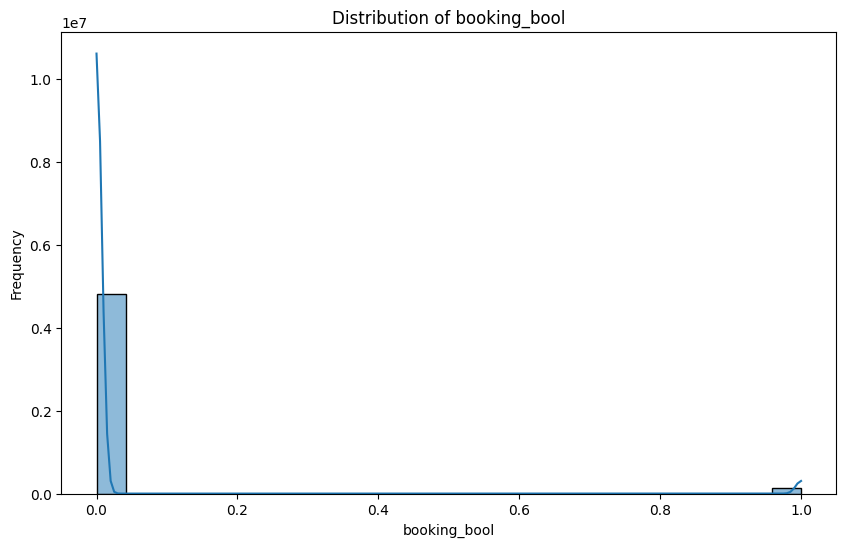

In [22]:
explore_column(df, "booking_bool")

In [ ]:
df_numeric = df.select_dtypes(include=[np.number])

# Remove the target variable from the numeric dataframe

In [36]:
# train-test split
from sklearn.model_selection import train_test_split
X = df.drop(columns=["booking_bool", "click_bool", "gross_bookings_usd", "srch_id", "date_time"])
y1 = df["booking_bool"]
y2 = df["click_bool"]
X_train, X_test, y_train, y_test = train_test_split(X, y1, test_size=0.2, random_state=42)
X_train, X_test, y_train2, y_test2 = train_test_split(X, y2, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (3966677, 49)
X_test shape: (991670, 49)
y_train shape: (3966677,)
y_test shape: (991670,)


In [45]:

sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train,
)


# Train the model
model_book = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model_book.fit(X_train, y_train, sample_weight=sample_weights)


/Users/urbansirca/miniconda3/envs/datascience/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [16:46:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

Booking Bool Model
Accuracy: 0.7534421733036192
F1 Score: 0.14676158570630932
Precision: 0.08125381577625447
Recall: 0.7573291075415977
ROC AUC: 0.7553296573495785
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.75      0.86    963904
           1       0.08      0.76      0.15     27766

    accuracy                           0.75    991670
   macro avg       0.54      0.76      0.50    991670
weighted avg       0.97      0.75      0.84    991670

Confusion Matrix:
[[726138 237766]
 [  6738  21028]]


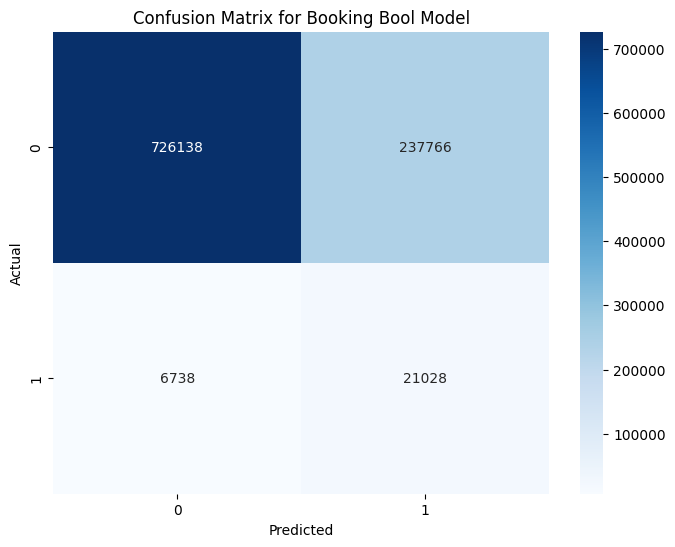

In [46]:
# make predictions
y_pred = model_book.predict(X_test)
# evaluate the model
print("Booking Bool Model")
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"F1 Score: {f1_score(y_test, y_pred)}")
print(f"Precision: {precision_score(y_test, y_pred)}")
print(f"Recall: {recall_score(y_test, y_pred)}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred)}")
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix for Booking Bool Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [47]:
# feature importance
importances = model_book.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]
# Print the feature ranking
print("Feature ranking:")
for f in range(X.shape[1]):
    print(f"{f + 1}. feature {feature_names[indices[f]]} ({importances[indices[f]]})")

Feature ranking:
1. feature random_bool (0.34760773181915283)
2. feature position (0.24920502305030823)
3. feature prop_location_score2 (0.02580105885863304)
4. feature price_usd (0.021363353356719017)
5. feature prop_starrating (0.018591802567243576)
6. feature srch_length_of_stay (0.01753443107008934)
7. feature promotion_flag (0.017018867656588554)
8. feature prop_brand_bool (0.0139088686555624)
9. feature prop_review_score (0.01362727489322424)
10. feature prop_location_score1 (0.011805467307567596)
11. feature srch_booking_window (0.01117709744721651)
12. feature visitor_hist_adr_usd (0.010797507129609585)
13. feature srch_adults_count (0.009886649437248707)
14. feature srch_room_count (0.009625639766454697)
15. feature comp8_rate (0.00949826929718256)
16. feature srch_query_affinity_score (0.009369514882564545)
17. feature prop_log_historical_price (0.008632775396108627)
18. feature srch_children_count (0.008497724309563637)
19. feature comp5_rate (0.008367746137082577)
20. featu